# Agentic-DEE Analysis
Analysis of agent-driven DEE parameter exploration across 1VII, 1PGB, and 1L2Y.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load experiment logs

In [4]:
LOG_FILE = Path("../data/logs/experiments.jsonl")

records = []
with open(LOG_FILE) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Loaded {len(records)} experiment records")

# Flatten into a DataFrame
rows = []
for r in records:
    row = {
        "id": r["id"],
        "timestamp": r["timestamp"],
        "protein": r["protein"],
        "run_type": r.get("run_type", "agent"),
        "rationale": r.get("rationale", ""),
        # parameters
        "ex1": r["parameters"].get("ex1", False),
        "ex2": r["parameters"].get("ex2", False),
        "ex1aro": r["parameters"].get("ex1aro", False),
        "use_input_sc": r["parameters"].get("use_input_sc", False),
        "designable_region": r["parameters"].get("designable_region", "all"),
        # metrics
        "initial_score": r["metrics"].get("initial_score"),
        "final_score": r["metrics"].get("final_score"),
        "score_improvement": r["metrics"].get("score_improvement"),
        "rotamers_pre_dee": r["metrics"].get("rotamers_pre_dee"),
        "runtime_seconds": r["metrics"].get("runtime_seconds"),
        "designable_residues": r["metrics"].get("designable_residues"),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601", utc=True)

# Create a readable parameter config label
def config_label(row):
    parts = []
    if row["ex1"]: parts.append("ex1")
    if row["ex2"]: parts.append("ex2")
    if row["ex1aro"]: parts.append("ex1aro")
    if row["use_input_sc"]: parts.append("isc")
    sampling = "+".join(parts) if parts else "none"
    return f"{sampling}/{row['designable_region']}"

df["config"] = df.apply(config_label, axis=1)

print(f"Proteins: {df['protein'].unique()}")
print(f"Run types: {df['run_type'].value_counts().to_dict()}")
df.head()

Loaded 34 experiment records
Proteins: <StringArray>
['1VII', '1PGB', '1L2Y']
Length: 3, dtype: str
Run types: {'agent': 33, 'baseline': 1}


,id,timestamp,protein,run_type,rationale,ex1,ex2,ex1aro,use_input_sc,designable_region,initial_score,final_score,score_improvement,rotamers_pre_dee,runtime_seconds,designable_residues,config
0,run_baseline_1VII,2026-03-30 16:20:38.912740+00:00,1VII,baseline,Baseline run with PyRosetta defaults.,False,False,False,True,all,518.746,38.342,480.404,14992.0,49.58,NaN,isc/all
1,test001,2026-03-30 16:32:16.938531+00:00,1VII,agent,Baseline run with default parameters.,True,True,False,False,all,NaN,38.342,NaN,NaN,49.58,NaN,ex1+ex2/all
2,run_20260414_011345_545908,2026-04-14 01:13:45.546013+00:00,1VII,agent,Dahiyat & Mayo 1997 reference configuration. M...,False,False,False,False,core,518.746,503.949,14.798,105.0,0.19,1.0,none/core
3,run_20260414_011345_797636,2026-04-14 01:13:45.797708+00:00,1VII,agent,Conservative modern approach: add only ex1 sam...,True,False,False,False,core,518.746,503.949,14.798,275.0,0.12,1.0,ex1/core
4,run_20260414_011345_924735,2026-04-14 01:13:45.924792+00:00,1VII,agent,Core residues with input sidechain included. M...,False,False,False,True,core,518.746,503.949,14.798,106.0,0.05,1.0,isc/core


## 2. Summary table

In [5]:
# Filter out failed/trivial runs (score > 200 usually means core-only with 1 residue)
df_valid = df[df["final_score"] < 200].copy()

print(f"Valid runs: {len(df_valid)} / {len(df)} total")
print(f"Excluded {len(df) - len(df_valid)} trivial runs (score > 200 REU)\n")

summary = df_valid.groupby(["protein", "config"]).agg(
    final_score=("final_score", "mean"),
    runtime_s=("runtime_seconds", "mean"),
    rotamers=("rotamers_pre_dee", "mean"),
    n_runs=("id", "count"),
).round(2).sort_values(["protein", "final_score"])

print(summary.to_string())

Valid runs: 14 / 34 total
Excluded 20 trivial runs (score > 200 REU)

                                final_score  runtime_s  rotamers  n_runs
protein config                                                          
1PGB    ex1+ex1aro+isc/all          -166.53      83.24   19607.0       1
        ex2+isc/all                 -165.08     133.38   17374.0       1
        ex1+isc/all                 -162.33      80.13   19607.0       1
        ex1+ex2+isc/all             -161.19     150.24   29612.0       1
        ex1+ex1aro+isc/core            9.63       1.79    1528.0       1
        ex1+isc/core                   9.63       1.88    1528.0       1
        isc/core                       9.63       0.46     560.0       1
        none/core                     11.46       0.45     558.0       1
1VII    ex1+ex2/all                   38.34      49.58       NaN       1
        isc/all                       38.34      49.58   14992.0       1
        ex1/all                       39.21      51.93

## 3. Score vs Runtime — Pareto frontier

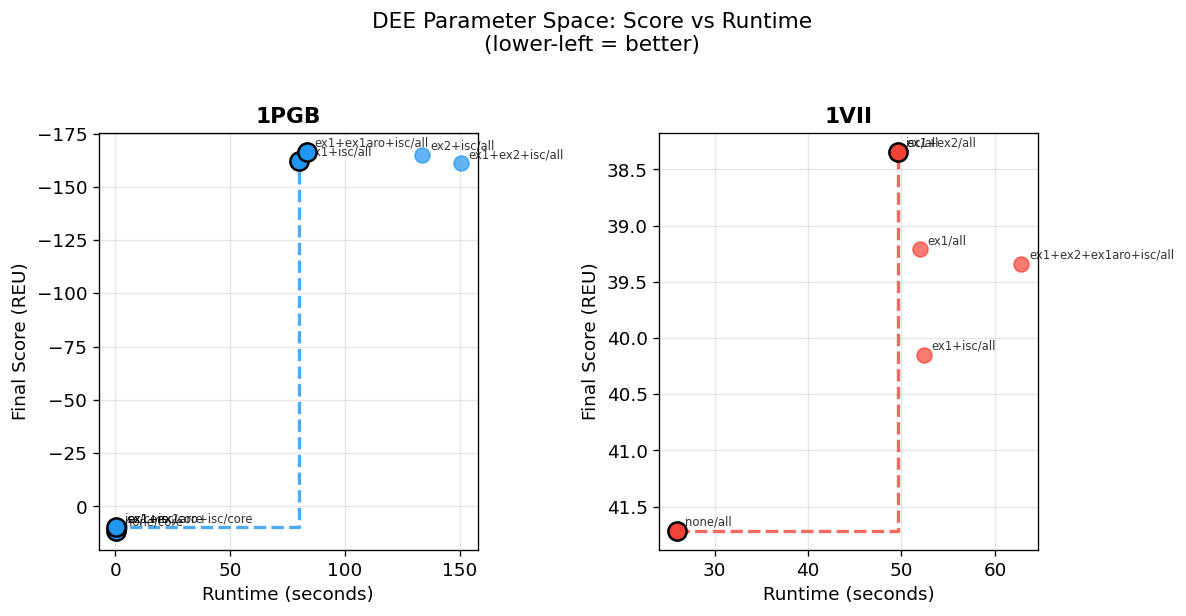

Saved: ../results/pareto_frontier.png


In [6]:
proteins = sorted(df_valid["protein"].unique())
colors = {p: c for p, c in zip(proteins, ["#2196F3", "#F44336", "#4CAF50"])}

fig, axes = plt.subplots(1, len(proteins), figsize=(5 * len(proteins), 5), sharey=False)
if len(proteins) == 1:
    axes = [axes]

def pareto_frontier(df, x_col, y_col):
    """Return rows that are Pareto-optimal (minimize both x and y)."""
    df = df.sort_values(x_col).reset_index(drop=True)
    pareto = []
    min_y = float("inf")
    for _, row in df.iterrows():
        if row[y_col] < min_y:
            min_y = row[y_col]
            pareto.append(row)
    return pd.DataFrame(pareto)

for ax, protein in zip(axes, proteins):
    sub = df_valid[df_valid["protein"] == protein].copy()
    color = colors[protein]

    # Scatter all runs
    ax.scatter(
        sub["runtime_seconds"], sub["final_score"],
        c=color, alpha=0.7, s=80, zorder=3
    )

    # Label each point with its config
    for _, row in sub.iterrows():
        ax.annotate(
            row["config"],
            (row["runtime_seconds"], row["final_score"]),
            textcoords="offset points", xytext=(5, 3),
            fontsize=7, alpha=0.8
        )

    # Pareto frontier
    pareto = pareto_frontier(sub, "runtime_seconds", "final_score")
    if len(pareto) > 1:
        ax.step(
            pareto["runtime_seconds"], pareto["final_score"],
            where="post", color=color, linewidth=2,
            linestyle="--", alpha=0.8, label="Pareto frontier"
        )
        ax.scatter(
            pareto["runtime_seconds"], pareto["final_score"],
            c=color, s=120, zorder=4, edgecolors="black", linewidth=1.5
        )

    ax.set_title(f"{protein}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Runtime (seconds)")
    ax.set_ylabel("Final Score (REU)")
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()  # lower score is better, so invert so "better" is up

plt.suptitle("DEE Parameter Space: Score vs Runtime\n(lower-left = better)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/pareto_frontier.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/pareto_frontier.png")

## 4. Parameter sensitivity — which flags matter most?

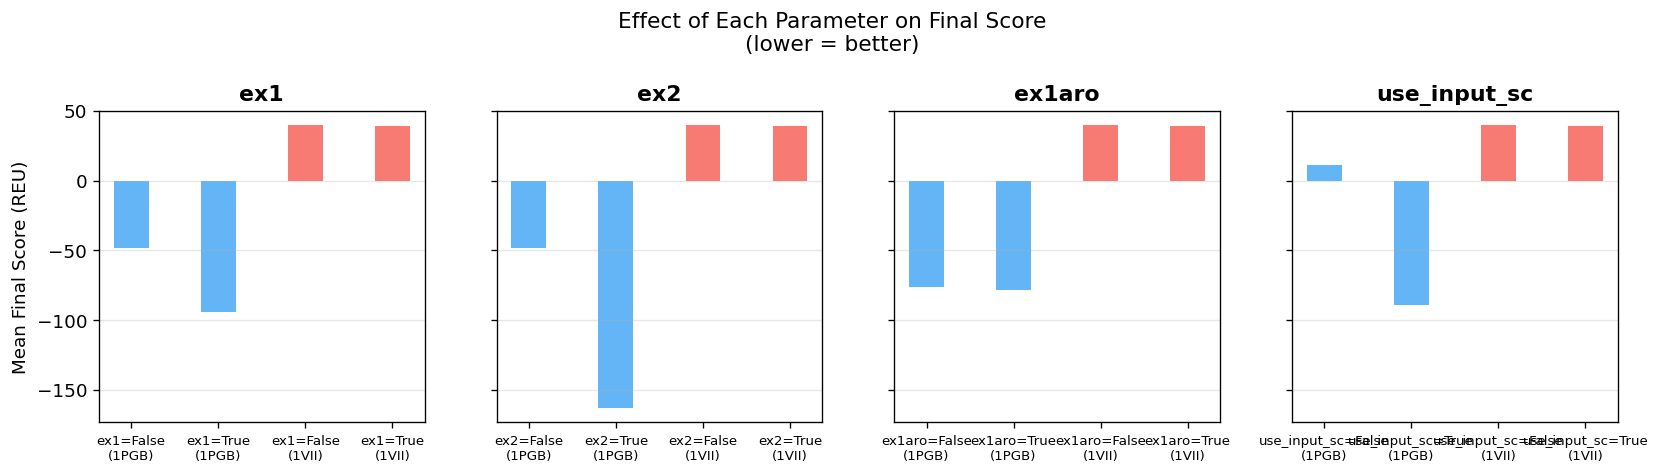

Saved: ../results/parameter_sensitivity.png


In [7]:
params = ["ex1", "ex2", "ex1aro", "use_input_sc"]

fig, axes = plt.subplots(1, len(params), figsize=(14, 4), sharey=True)

for ax, param in zip(axes, params):
    for protein in proteins:
        sub = df_valid[df_valid["protein"] == protein]
        means = sub.groupby(param)["final_score"].mean()
        labels = [f"{param}=True" if v else f"{param}=False" for v in means.index]
        ax.bar(
            [l + f"\n({protein})" for l in labels],
            means.values,
            color=colors[protein], alpha=0.7, width=0.4,
        )

    ax.set_title(param, fontweight="bold")
    ax.set_ylabel("Mean Final Score (REU)" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3, axis="y")
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Effect of Each Parameter on Final Score\n(lower = better)",
             fontsize=13)
plt.tight_layout()
plt.savefig("../results/parameter_sensitivity.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/parameter_sensitivity.png")

## 5. Rotamers vs Score — pruning efficiency

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

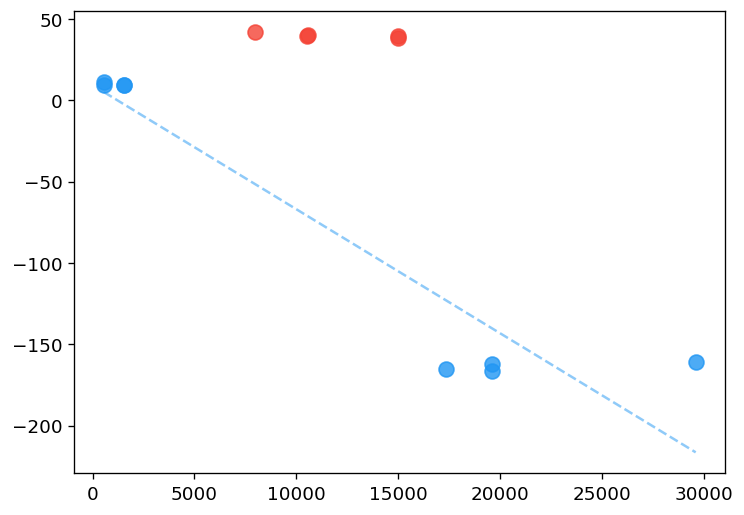

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for protein in proteins:
    sub = df_valid[df_valid["protein"] == protein]
    ax.scatter(
        sub["rotamers_pre_dee"], sub["final_score"],
        label=protein, color=colors[protein],
        alpha=0.8, s=80
    )
    # Trend line
    if len(sub) > 2:
        z = np.polyfit(sub["rotamers_pre_dee"], sub["final_score"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sub["rotamers_pre_dee"].min(),
                              sub["rotamers_pre_dee"].max(), 100)
        ax.plot(x_range, p(x_range), color=colors[protein],
                linestyle="--", alpha=0.5)

ax.set_xlabel("Rotamers Pre-DEE")
ax.set_ylabel("Final Score (REU)")
ax.set_title("Rotamer Count vs Final Score\n(does more sampling help?)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/rotamers_vs_score.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/rotamers_vs_score.png")

## 6. Cross-protein comparison — baseline vs best agent config

In [9]:
# Dahiyat & Mayo paper-faithful config: no extra sampling, all residues
paper_config = df_valid[
    (df_valid["ex1"] == False) &
    (df_valid["ex2"] == False) &
    (df_valid["ex1aro"] == False) &
    (df_valid["use_input_sc"] == False) &
    (df_valid["designable_region"] == "all")
]

# Modern baseline: ex1+ex2, all residues
modern_config = df_valid[
    (df_valid["ex1"] == True) &
    (df_valid["ex2"] == True) &
    (df_valid["designable_region"] == "all")
]

# Best agent config per protein (lowest final score)
best_agent = df_valid.loc[df_valid.groupby("protein")["final_score"].idxmin()]

print("=== Paper-faithful config (no extra sampling) ===")
print(paper_config[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee"]].to_string(index=False))

print("\n=== Modern baseline (ex1+ex2) ===")
print(modern_config[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee"]].to_string(index=False))

print("\n=== Best agent-discovered config per protein ===")
print(best_agent[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee", "rationale"]].to_string(index=False))

=== Paper-faithful config (no extra sampling) ===
protein   config  final_score  runtime_seconds  rotamers_pre_dee
   1VII none/all       41.714            25.94            7982.0

=== Modern baseline (ex1+ex2) ===
protein                 config  final_score  runtime_seconds  rotamers_pre_dee
   1VII            ex1+ex2/all       38.342            49.58               NaN
   1VII ex1+ex2+ex1aro+isc/all       39.339            62.78           14992.0
   1PGB        ex1+ex2+isc/all     -161.192           150.24           29612.0

=== Best agent-discovered config per protein ===
protein             config  final_score  runtime_seconds  rotamers_pre_dee                                                                                                                                                                                       rationale
   1PGB ex1+ex1aro+isc/all     -166.532            83.24           19607.0 Run 7: Test aromatic sampling on all-residue design. Hypothesis: aromatic chi

## 7. Agent decision log — rationale review

In [10]:
# Print agent rationale for each run in order — useful for writeup
agent_runs = df[df["run_type"] == "agent"].sort_values("timestamp")

for protein in proteins:
    print(f"\n{'='*60}")
    print(f"  {protein}")
    print(f"{'='*60}")
    sub = agent_runs[agent_runs["protein"] == protein]
    for i, (_, row) in enumerate(sub.iterrows(), 1):
        score_str = f"{row['final_score']:.3f} REU" if pd.notna(row['final_score']) else "N/A"
        runtime_str = f"{row['runtime_seconds']:.1f}s" if pd.notna(row['runtime_seconds']) else "N/A"
        print(f"\nRun {i}: {row['config']}")
        print(f"  Score: {score_str} | Runtime: {runtime_str} | Rotamers: {row['rotamers_pre_dee']}")
        print(f"  Rationale: {row['rationale'][:200]}{'...' if len(str(row['rationale'])) > 200 else ''}")


  1PGB

Run 1: none/core
  Score: 11.458 REU | Runtime: 0.5s | Rotamers: 558.0
  Rationale: Run 1: Dahiyat & Mayo (1997) baseline. This represents the original DEE algorithm with minimal rotamer sampling. Provides a reference point for comparison and should be fast but may sacrifice sequence...

Run 2: ex1+ex2+isc/all
  Score: -161.192 REU | Runtime: 150.2s | Rotamers: 29612.0
  Rationale: Run 2: Modern Rosetta default. Full rotamer sampling with input sidechain and all residues designable. Expected to produce best scores but slower and less pruning.

Run 3: ex1+isc/core
  Score: 9.626 REU | Runtime: 1.9s | Rotamers: 1528.0
  Rationale: Run 3: Conservative modern variant. ex1 sampling + input_sc + core-only. Aims for balance between search quality and computational cost. Hypothesis: good middle ground.

Run 4: ex1+ex1aro+isc/core
  Score: 9.626 REU | Runtime: 1.8s | Rotamers: 1528.0
  Rationale: Run 4: Test aromatic extra sampling impact on core-only design. Hypothesis: aromatic chi1 

## 8. Key findings summary

In [11]:
print("KEY FINDINGS")
print("="*60)

for protein in proteins:
    sub = df_valid[df_valid["protein"] == protein]
    if sub.empty:
        continue

    best = sub.loc[sub["final_score"].idxmin()]
    fastest = sub.loc[sub["runtime_seconds"].idxmin()]
    paper = sub[
        (sub["ex1"] == False) & (sub["ex2"] == False) &
        (sub["ex1aro"] == False) & (sub["use_input_sc"] == False) &
        (sub["designable_region"] == "all")
    ]
    modern = sub[
        (sub["ex1"] == True) & (sub["ex2"] == True) &
        (sub["designable_region"] == "all")
    ]

    print(f"\n{protein}:")
    print(f"  Best score    : {best['final_score']:.3f} REU  [{best['config']}]  {best['runtime_seconds']:.1f}s")
    print(f"  Fastest       : {fastest['runtime_seconds']:.1f}s  [{fastest['config']}]  score={fastest['final_score']:.3f} REU")
    if not paper.empty:
        p = paper.iloc[0]
        print(f"  Paper-faithful: {p['final_score']:.3f} REU  {p['runtime_seconds']:.1f}s  {p['rotamers_pre_dee']} rotamers")
    if not modern.empty:
        m = modern.iloc[0]
        print(f"  Modern default: {m['final_score']:.3f} REU  {m['runtime_seconds']:.1f}s  {m['rotamers_pre_dee']} rotamers")
    if not paper.empty and not modern.empty:
        p, m = paper.iloc[0], modern.iloc[0]
        score_diff = abs(p['final_score'] - m['final_score'])
        runtime_ratio = m['runtime_seconds'] / p['runtime_seconds']
        print(f"  Tradeoff      : paper config is {runtime_ratio:.1f}x faster, {score_diff:.3f} REU worse")

KEY FINDINGS

1PGB:
  Best score    : -166.532 REU  [ex1+ex1aro+isc/all]  83.2s
  Fastest       : 0.5s  [none/core]  score=11.458 REU
  Modern default: -161.192 REU  150.2s  29612.0 rotamers

1VII:
  Best score    : 38.342 REU  [isc/all]  49.6s
  Fastest       : 25.9s  [none/all]  score=41.714 REU
  Paper-faithful: 41.714 REU  25.9s  7982.0 rotamers
  Modern default: 38.342 REU  49.6s  nan rotamers
  Tradeoff      : paper config is 1.9x faster, 3.372 REU worse
